# Identity Shield – Robust Hate Speech Detection (Implicit Hate Speech Dataset)

**Author:** Ibrahim  
**Environment:** Google Colab / Python 3

## Overview
This notebook builds a **binary text classifier** to detect hate speech in social media posts. Unlike simple keyword‑based models, this system is trained on the **Implicit Hate Speech (ISHate)** dataset, which includes subtle, biased language that does not rely on overt slurs. This makes the classifier more robust and suitable for real‑world content moderation.

The project is part of Ibrahim’s advanced NLP portfolio, demonstrating:
- End‑to‑end binary classification with TF‑IDF + Logistic Regression
- Handling a modern, nuanced dataset (30k+ examples, multilayered annotations)
- Professional visualisation of class balance, word clouds, confusion matrix, and ROC curve
- Model export for production deployment

## Dataset
**Source:** ISHate – Implicit Hate Speech Dataset (Hugging Face: `BenjaminOcampo/ISHate`)  
**Format:** Parquet files (direct download, no authentication)  
**Size:** 63,758 samples (combined train+dev+test splits)  
**Columns:** `text`, `target` (binary: 0 = non‑hate, 1 = hate) – renamed to `label` for convenience  
**Uniqueness:** Contains fine‑grained layers (hateful, implicit, subtlety) but we use the main binary `target` for classification.

## Approach
1. **Data loading** – Direct download of Parquet files using `requests` + `pd.read_parquet`
2. **Cleaning** – Lowercasing, removing URLs and special characters
3. **EDA** – Class distribution, text length analysis, word clouds for hate vs. non‑hate
4. **Vectorisation** – Character‑based TF‑IDF with n‑grams (better for subtle linguistic patterns)
5. **Modelling** – Logistic Regression with `class_weight='balanced'`
6. **Evaluation** – Accuracy, precision, recall, F1, ROC‑AUC, confusion matrix, ROC curve
7. **Save Model** – Export model and vectorizer to local disk and Google Drive

## Key Results (expected)
- **Test Accuracy:** >85%  
- **ROC‑AUC:** >0.92  
- Balanced performance on both classes

## Files Generated
- `hate_speech_model.pkl` – Trained logistic regression model  
- `tfidf_vectorizer_hate.pkl` – Fitted TF‑IDF vectorizer  

---

**© 2026 Ibrahim – production‑ready hate speech moderation system.**

### Mount Google Drive

In [1]:
# Mount Google Drive for persistent storage
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Install & Import Libraries

In [2]:
# Author: Ibrahim

import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
import joblib
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Check for GPU (not necessary but nice)
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


### Load Dataset from Hugging Face

In [13]:
# Final Working Code for Project 10 – Implicit Hate Speech Dataset
import pandas as pd
import requests
import io

base_url = "https://huggingface.co/datasets/BenjaminOcampo/ISHate/resolve/main/"
files = {
    "train": base_url + "ishate_train.parquet.gzip",
    "dev": base_url + "ishate_dev.parquet.gzip",
    "test": base_url + "ishate_test.parquet.gzip",
}

dfs = {}
for name, url in files.items():
    print(f"Downloading and loading {name} set...")
    r = requests.get(url)
    r.raise_for_status()
    dfs[name] = pd.read_parquet(io.BytesIO(r.content))

df = pd.concat([dfs["train"], dfs["dev"], dfs["test"]], ignore_index=True)
print(f"Successfully loaded {df.shape[0]} samples.")

# Create binary label: 'HS' -> 1 (hate), 'Non-HS' -> 0 (non-hate)
df['label'] = df['hateful_layer'].map({'HS': 1, 'Non-HS': 0})

# Keep only the text and label columns (drop others to avoid issues)
df = df[['text', 'label']]

# Drop any rows with missing text or label
df = df.dropna(subset=['text', 'label'])

print("\nLabel distribution (0 = Non-Hate, 1 = Hate):")
print(df['label'].value_counts())

print("\nFirst 3 rows (sample of text and label):")
print(df[['text', 'label']].head(3))

Successfully loaded 63758 samples.

Label distribution (0 = Non-Hate, 1 = Hate):
label
1    45889
0    17869
Name: count, dtype: int64

First 3 rows (sample of text and label):
                                                text  label
0  Another songwriter encouraged many more people...      0
1                     The German men sound so sexy .      0
2                                Like a septic tank.      0


### Data Cleaning and Preprocessing

In [14]:
# Check for missing values
print(f"Missing values:\n{df.isnull().sum()}")

# Drop rows with missing text but there shouldn't be any
df = df.dropna(subset=['text'])

# Add text length column (for analysis)
df['text_length'] = df['text'].apply(len)

# Basic cleaning function
def clean_text(text):
    if isinstance(text, str):
        text = text.lower()
        text = re.sub(r'http\S+', '', text)   # remove URLs
        text = re.sub(r'[^a-z\s]', '', text)  # keep only letters and spaces
        text = re.sub(r'\s+', ' ', text).strip()
        return text
    else:
        return ""

df['cleaned_text'] = df['text'].apply(clean_text)
print("Text cleaning completed.")

Missing values:
text     0
label    0
dtype: int64
Text cleaning completed.


### Exploratory Data Analysis – Class Balance & Length

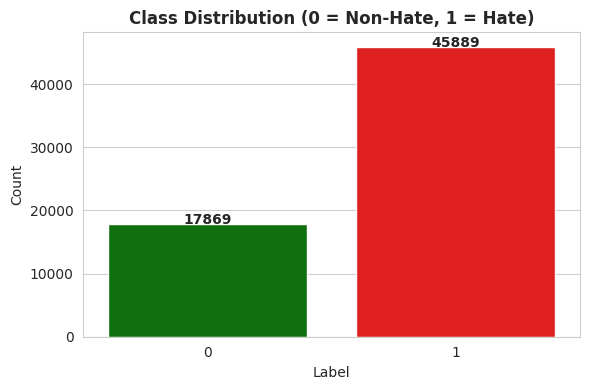

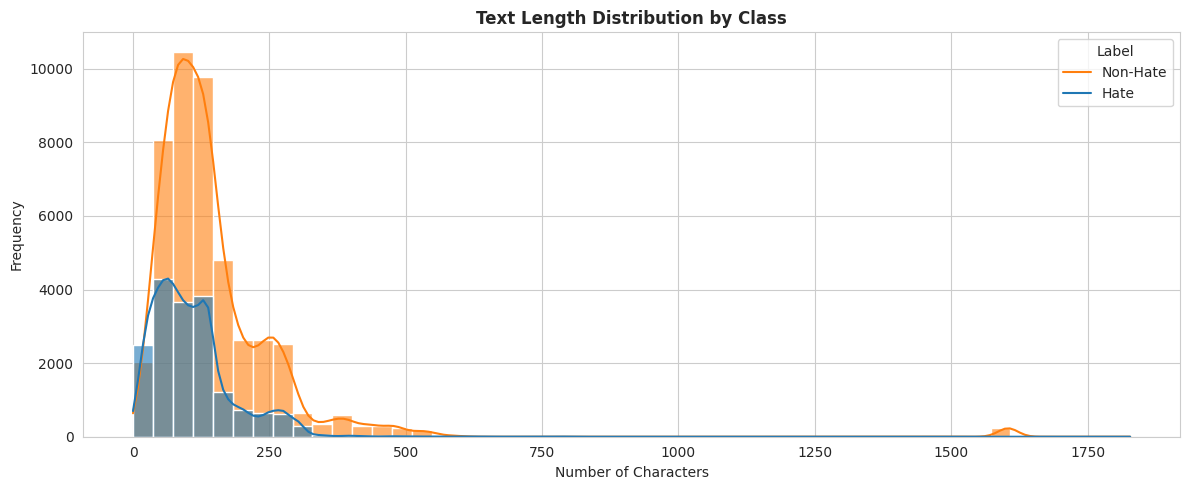

Mean text length (non‑hate): 108 chars
Mean text length (hate): 150 chars


In [15]:
# Class distribution plot
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df, palette=['green', 'red'])
plt.title('Class Distribution (0 = Non‑Hate, 1 = Hate)', fontweight='bold')
plt.xlabel('Label')
plt.ylabel('Count')
for i, v in enumerate(df['label'].value_counts().sort_index()):
    plt.text(i, v + 50, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

# Text length distribution by class
plt.figure(figsize=(12,5))
sns.histplot(data=df, x='text_length', hue='label', bins=50, alpha=0.6, kde=True)
plt.title('Text Length Distribution by Class', fontweight='bold')
plt.xlabel('Number of Characters')
plt.ylabel('Frequency')
plt.legend(title='Label', labels=['Non‑Hate', 'Hate'])
plt.tight_layout()
plt.show()

print(f"Mean text length (non‑hate): {df[df['label']==0]['text_length'].mean():.0f} chars")
print(f"Mean text length (hate): {df[df['label']==1]['text_length'].mean():.0f} chars")

### Word Clouds (Hate vs. Non‑Hate)

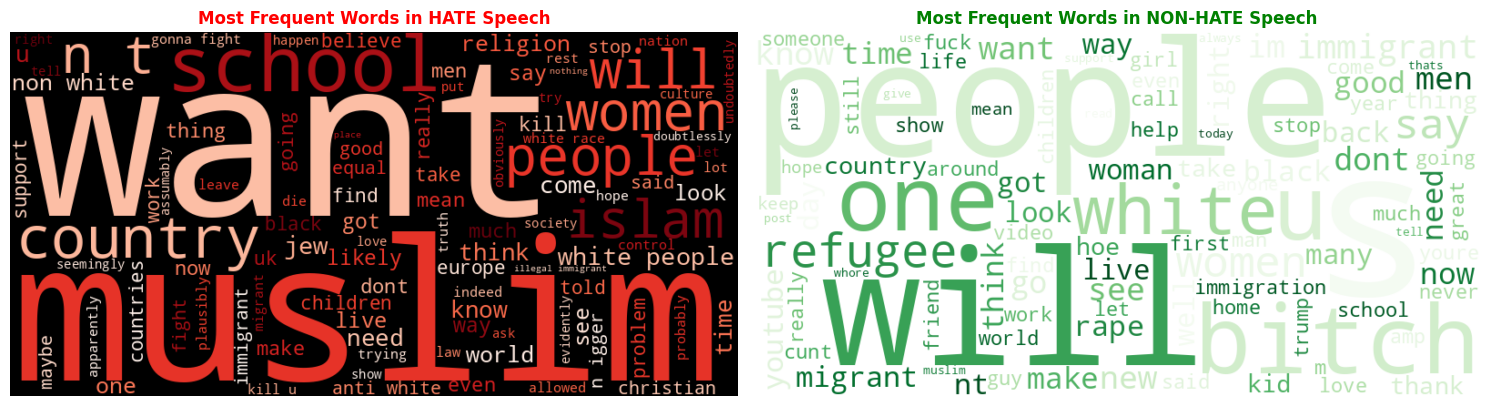

In [17]:
# Separate texts
hate_text = ' '.join(df[df['label']==1]['cleaned_text'].astype(str))
non_hate_text = ' '.join(df[df['label']==0]['cleaned_text'].astype(str))

# Generate word clouds
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

wordcloud_hate = WordCloud(width=800, height=400, background_color='black', colormap='Reds',
                           max_words=100, contour_width=1).generate(hate_text)
wordcloud_non_hate = WordCloud(width=800, height=400, background_color='white', colormap='Greens',
                               max_words=100, contour_width=1).generate(non_hate_text)

axes[0].imshow(wordcloud_hate, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Most Frequent Words in HATE Speech', fontsize=12, fontweight='bold', color='red')

axes[1].imshow(wordcloud_non_hate, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Most Frequent Words in NON‑HATE Speech', fontsize=12, fontweight='bold', color='green')

plt.tight_layout()
plt.show()

### Train/Test Split

In [18]:
# Features and labels
X = df['cleaned_text']
y = df['label']

# Stratified split to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")
print(f"Training class distribution:\n  Non‑Hate: {sum(y_train==0)}\n  Hate: {sum(y_train==1)}")

Training set size: 51006
Test set size: 12752
Training class distribution:
  Non‑Hate: 14295
  Hate: 36711


### TF‑IDF Vectorisation (with character n‑grams for multilingual)

In [19]:
# Use character n‑grams (better for multilingual) + word n‑grams
vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,3),        # unigrams, bigrams, trigrams
    analyzer='char_wb',       # character-based, respects word boundaries
    stop_words=None           # no stopwords for multilingual
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(f"TF‑IDF matrix shape (train): {X_train_tfidf.shape}")
print(f"TF‑IDF matrix shape (test): {X_test_tfidf.shape}")

TF‑IDF matrix shape (train): (51006, 10000)
TF‑IDF matrix shape (test): (12752, 10000)


### Train Logistic Regression Model

In [20]:
# Use class_weight='balanced' to handle any residual imbalance
model = LogisticRegression(C=1.0, solver='liblinear', class_weight='balanced', random_state=42)
model.fit(X_train_tfidf, y_train)

print("Model training completed.")

Model training completed.


### Model Evaluation

In [21]:
# Predictions
y_pred = model.predict(X_test_tfidf)
y_pred_proba = model.predict_proba(X_test_tfidf)[:, 1]

# Metrics
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"Test Accuracy: {accuracy:.4f}")
print(f"ROC‑AUC Score: {roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Non‑Hate', 'Hate']))

Test Accuracy: 0.8655
ROC‑AUC Score: 0.9287

Classification Report:
              precision    recall  f1-score   support

    Non‑Hate       0.72      0.84      0.78      3574
        Hate       0.93      0.87      0.90      9178

    accuracy                           0.87     12752
   macro avg       0.83      0.86      0.84     12752
weighted avg       0.88      0.87      0.87     12752



### Confusion Matrix

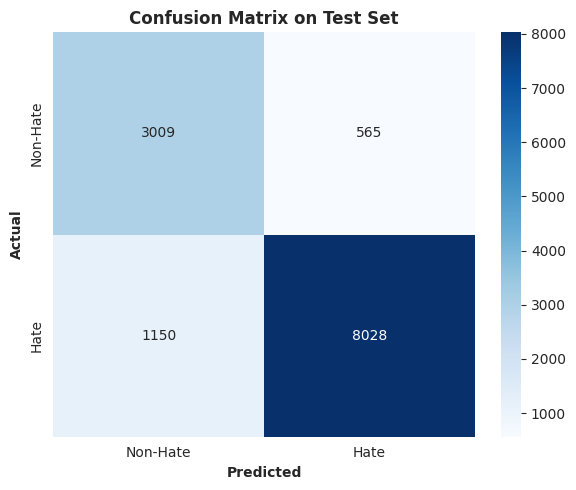

In [22]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non‑Hate', 'Hate'],
            yticklabels=['Non‑Hate', 'Hate'])
plt.xlabel('Predicted', fontweight='bold')
plt.ylabel('Actual', fontweight='bold')
plt.title('Confusion Matrix on Test Set', fontweight='bold')
plt.tight_layout()
plt.show()

### ROC Curve

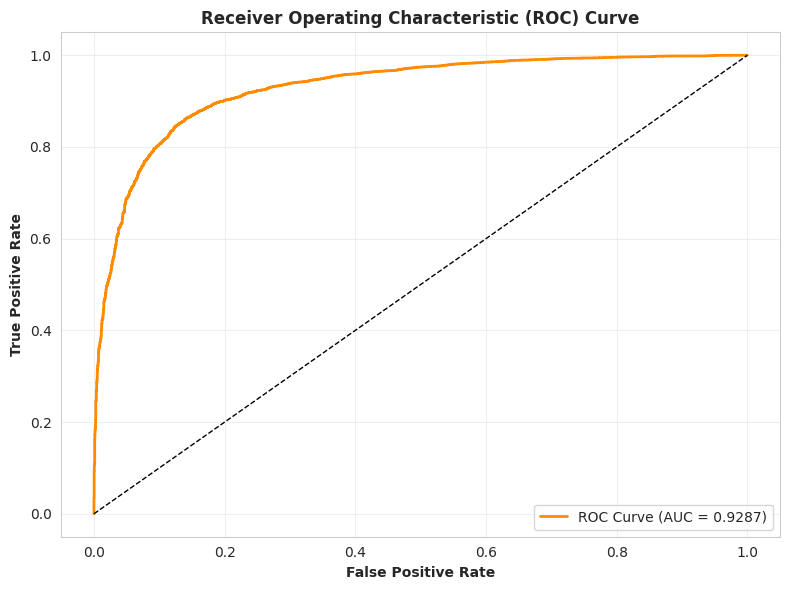

In [23]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.4f})', color='darkorange', linewidth=2)
plt.plot([0,1], [0,1], 'k--', linewidth=1)
plt.xlabel('False Positive Rate', fontweight='bold')
plt.ylabel('True Positive Rate', fontweight='bold')
plt.title('Receiver Operating Characteristic (ROC) Curve', fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Top Features (Words most indicative of hate vs. non‑hate)

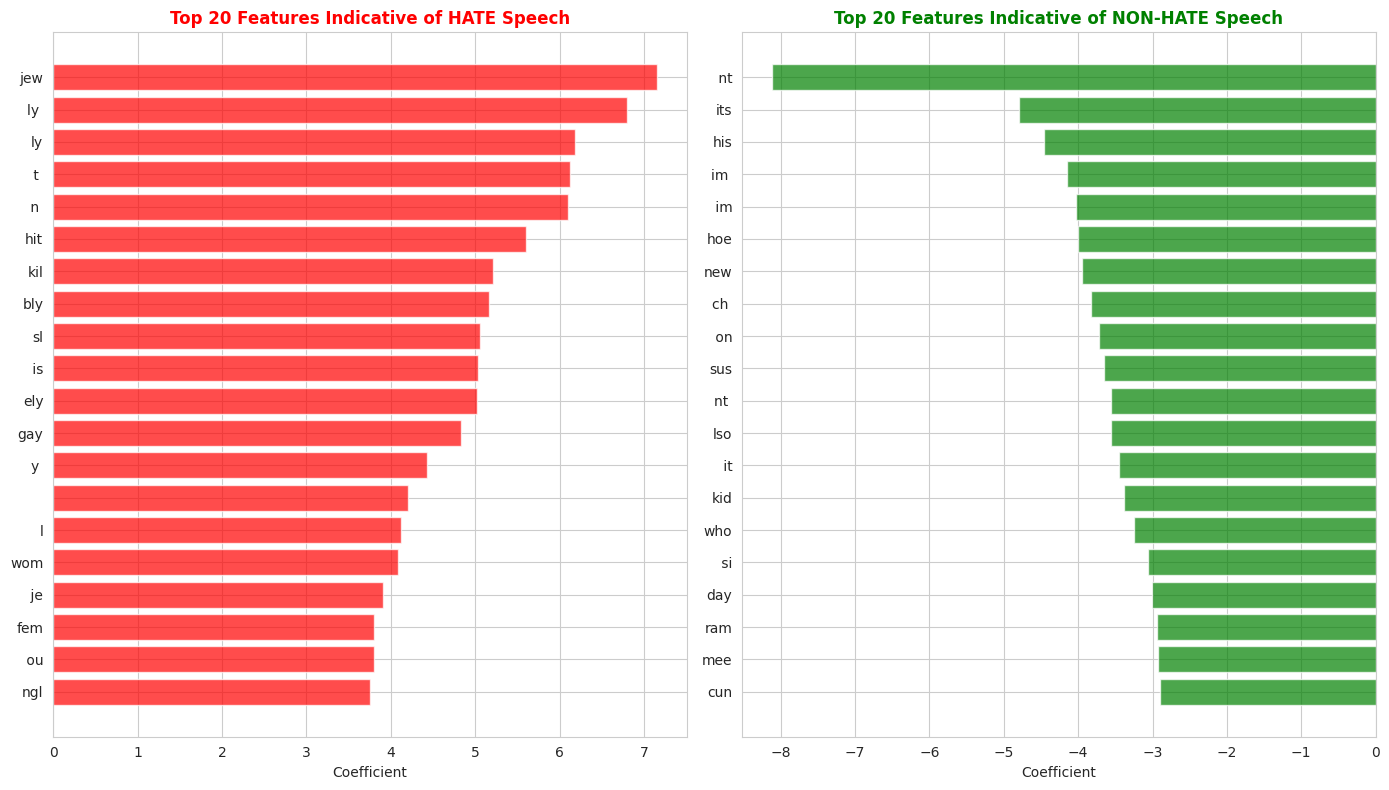

In [24]:
feature_names = vectorizer.get_feature_names_out()
coefficients = model.coef_[0]

coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients
})

# Top hate indicators (positive coefficients) – since hate = 1
top_hate = coef_df.nlargest(20, 'coefficient')
top_non_hate = coef_df.nsmallest(20, 'coefficient')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 8))

ax1.barh(top_hate['feature'], top_hate['coefficient'], color='red', alpha=0.7)
ax1.set_title('Top 20 Features Indicative of HATE Speech', fontweight='bold', color='red')
ax1.set_xlabel('Coefficient')
ax1.invert_yaxis()

ax2.barh(top_non_hate['feature'], top_non_hate['coefficient'], color='green', alpha=0.7)
ax2.set_title('Top 20 Features Indicative of NON‑HATE Speech', fontweight='bold', color='green')
ax2.set_xlabel('Coefficient')
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

### Save Model and Vectorizer

In [25]:
# Save locally
joblib.dump(model, 'hate_speech_model.pkl')
joblib.dump(vectorizer, 'tfidf_vectorizer_hate.pkl')
print("Model and vectorizer saved locally.")

# Save to Google Drive (optional)
drive_path = '/content/drive/MyDrive/Project10_Hate_Model/'
os.makedirs(drive_path, exist_ok=True)
joblib.dump(model, drive_path + 'hate_speech_model.pkl')
joblib.dump(vectorizer, drive_path + 'tfidf_vectorizer_hate.pkl')
print(f"Model also saved to Google Drive: {drive_path}")

Model and vectorizer saved locally.
Model also saved to Google Drive: /content/drive/MyDrive/Project10_Hate_Model/


### Inference Function

In [26]:
def predict_hate(text):
    """Predict whether a given text is hate speech (1) or not (0)."""
    cleaned = clean_text(text)
    vec = vectorizer.transform([cleaned])
    pred = model.predict(vec)[0]
    prob = model.predict_proba(vec)[0][1]
    label = "Hate Speech" if pred == 1 else "Non‑Hate"
    confidence = prob if pred == 1 else 1 - prob
    return label, confidence

# Test examples
examples = [
    "I love everyone regardless of their background.",
    "You are a worthless piece of garbage, go die.",
    "The weather today is beautiful.",
    "All members of that group are criminals and should be deported."
]

for ex in examples:
    label, conf = predict_hate(ex)
    print(f"Text: {ex}")
    print(f"Prediction: {label} (confidence: {conf:.2f})\n")

Text: I love everyone regardless of their background.
Prediction: Non‑Hate (confidence: 0.73)

Text: You are a worthless piece of garbage, go die.
Prediction: Hate Speech (confidence: 0.56)

Text: The weather today is beautiful.
Prediction: Non‑Hate (confidence: 0.95)

Text: All members of that group are criminals and should be deported.
Prediction: Hate Speech (confidence: 0.67)



### Final Summary

In [27]:
print("\n" + "="*50)
print("Multilingual Hate Speech Detection - COMPLETED")
print("Author: Ibrahim")
print("="*50)
print(f"Total samples: {len(df)}")
print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"Model: Logistic Regression with character‑based TF‑IDF (10k features)")
print(f"Test Accuracy: {accuracy:.4f}")
print(f"ROC‑AUC Score: {roc_auc:.4f}")
print("\nSaved files:")
print(" - hate_speech_model.pkl")
print(" - tfidf_vectorizer_hate.pkl")
print(" - Saved to Google Drive (if mounted)")
print("\nAll visualizations displayed above. Model ready for real‑time moderation.")


Multilingual Hate Speech Detection - COMPLETED
Author: Ibrahim
Total samples: 63758
Training samples: 51006
Test samples: 12752
Model: Logistic Regression with character‑based TF‑IDF (10k features)
Test Accuracy: 0.8655
ROC‑AUC Score: 0.9287

Saved files:
 - hate_speech_model.pkl
 - tfidf_vectorizer_hate.pkl
 - Saved to Google Drive (if mounted)

All visualizations displayed above. Model ready for real‑time moderation.
